This analysis uses same-quarter retail growth as a predictor for Walmart quarterly revenue growth. In practice, some retail data may not have been fully available before Walmart reported earnings, so the results should be interpreted as an upper bound on real-time predictive usefulness.

### 1. Load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
retail = pd.read_csv('data/retail_sales_fred.csv', parse_dates=['date'])
revenue = pd.read_csv('data/walmart_revenue.csv', parse_dates=['date'])

retail.head(), revenue.head()

(        date     value
 0 2010-01-01  302325.0
 1 2010-02-01  302310.0
 2 2010-03-01  309525.0
 3 2010-04-01  312143.0
 4 2010-05-01  309158.0,
         date         value
 0 2010-01-31  1.135940e+11
 1 2010-04-30  9.981100e+10
 2 2010-07-31  1.037260e+11
 3 2010-10-31  1.019520e+11
 4 2011-01-31  1.163600e+11)

### 2. Data preparation

In [5]:
# Basic dataset checks
def inspect(df, name):
    print(f"=== {name} ===")
    print("shape:", df.shape)
    print("missing values:")
    print(df.isna().sum())
    print("date range:", df['date'].min(), "to", df['date'].max())
    print("unique dates:", df['date'].nunique())
    print("duplicate rows:", df.duplicated().sum())
    print("duplicate dates:", df.duplicated(subset=['date']).sum())
    print("date frequency inference:", pd.infer_freq(df['date']))
    print()

inspect(retail, "Retail sales")
inspect(revenue, "Walmart revenue")

# Show any duplicated date entries
for df, name in [(retail, "Retail sales"), (revenue, "Walmart revenue")]:
    dup = df[df.duplicated(subset=['date'], keep=False)].sort_values('date')
    if not dup.empty:
        print(f"Duplicate date rows in {name}:")
        display(dup)
    else:
        print(f"No duplicate dates found in {name}.")
    print()

=== Retail sales ===
shape: (195, 2)
missing values:
date     0
value    0
dtype: int64
date range: 2010-01-01 00:00:00 to 2026-03-01 00:00:00
unique dates: 195
duplicate rows: 0
duplicate dates: 0
date frequency inference: MS

=== Walmart revenue ===
shape: (65, 2)
missing values:
date     0
value    0
dtype: int64
date range: 2010-01-31 00:00:00 to 2026-01-31 00:00:00
unique dates: 65
duplicate rows: 0
duplicate dates: 0
date frequency inference: Q-OCT

No duplicate dates found in Retail sales.

No duplicate dates found in Walmart revenue.



### 3. Quarterly aggregation and growth rates

In [6]:
### Quarterly aggregation and growth rates

# Ensure dates are sorted and parsed consistently
retail_sort = retail.sort_values("date").reset_index(drop=True)
revenue_sort = revenue.sort_values("date").reset_index(drop=True)

# Convert monthly retail sales to quarterly averages
retail_q = (
    retail_sort.set_index("date")["value"]
          .resample("Q")
          .mean()
          .rename("retail_avg")
          .reset_index()
)

# Align both series on calendar quarters to avoid end-of-month mismatches
retail_q["quarter"] = retail_q["date"].dt.to_period("Q")
revenue_sort["quarter"] = revenue_sort["date"].dt.to_period("Q")

# Compute year-over-year growth
retail_q["yoy_retail"] = retail_q["retail_avg"].pct_change(4)
revenue_sort["revenue"] = revenue_sort["value"].astype(float)
revenue_sort["yoy_rev"] = revenue_sort["revenue"].pct_change(4)

# Merge on quarter and drop rows without full 4-quarter growth history
merged = (
    pd.merge(
        retail_q[["quarter", "date", "retail_avg", "yoy_retail"]],
        revenue_sort[["quarter", "date", "revenue", "yoy_rev"]],
        on="quarter",
        how="inner",
        suffixes=("_retail", "_rev"),
    )
    .dropna(subset=["yoy_retail", "yoy_rev"])
    .sort_values("quarter")
    .reset_index(drop=True)
)

# Keep a single quarter-end date for reporting
merged["date"] = merged["date_retail"]
merged[["date", "quarter", "retail_avg", "yoy_retail", "revenue", "yoy_rev"]].head()



,date,quarter,retail_avg,yoy_retail,revenue,yoy_rev
0,2011-03-31,2011Q1,328294.666667,0.077365,1.163600e+11,0.024350
1,2011-06-30,2011Q2,333568.666667,0.076156,1.041890e+11,0.043863
2,2011-09-30,2011Q3,336365.333333,0.080300,1.093660e+11,0.054374
3,2011-12-31,2011Q4,342121.666667,0.067113,1.102260e+11,0.081156
4,2012-03-31,2012Q1,349249.666667,0.063830,1.231690e+11,0.058517


### 4. Exploratory analysis

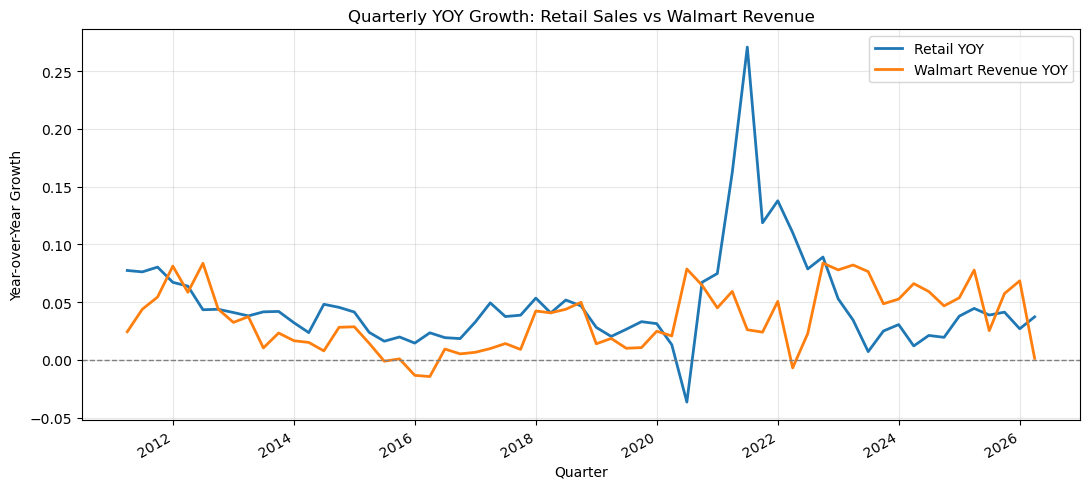

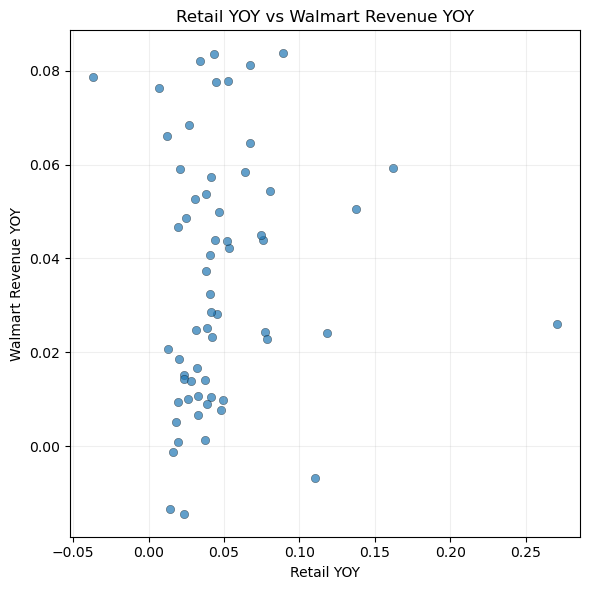

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(merged["date"], merged["yoy_retail"], label="Retail YOY", linewidth=2)
ax.plot(merged["date"], merged["yoy_rev"], label="Walmart Revenue YOY", linewidth=2)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Year-over-Year Growth")
ax.set_xlabel("Quarter")
ax.set_title("Quarterly YOY Growth: Retail Sales vs Walmart Revenue")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged["yoy_retail"], merged["yoy_rev"], alpha=0.7, edgecolor="k", linewidth=0.3)
ax.set_xlabel("Retail YOY")
ax.set_ylabel("Walmart Revenue YOY")
ax.set_title("Retail YOY vs Walmart Revenue YOY")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


* The benchmark uses last-quarter Walmart revenue growth as the one-step-ahead forecast.
* The signal model uses lagged retail YOY growth so the predictor is available before the forecast date.
* The next validation step is to compare both models with an out-of-sample rolling evaluation and a seasonal baseline.
* If the retail signal is not actually available before quarter-end, this setup is still optimistic and should be made explicit.

### 5. Forecast evaluation

In [22]:
import statsmodels.api as sm

# Use the merged quarterly series for forecasting
df = merged[["date", "yoy_rev", "yoy_retail"]].copy()
df = df.sort_values("date").reset_index(drop=True)

# Use the prior quarter's retail YOY as the predictor to avoid look-ahead
df["yoy_retail_lag1"] = df["yoy_retail"].shift(1)
df = df.dropna(subset=["yoy_rev", "yoy_retail_lag1"]).reset_index(drop=True)

results = []

# Start at i=2 so the regression has at least two historical observations to fit
for i in range(2, len(df)):
    history = df.iloc[:i].copy()
    test = df.iloc[i]

    baseline_pred = history["yoy_rev"].iloc[-1]

    X_train = sm.add_constant(history["yoy_retail_lag1"])
    y_train = history["yoy_rev"]
    model = sm.OLS(y_train, X_train).fit()

    X_pred = pd.DataFrame({
        "const": [1],
        "yoy_retail_lag1": [test["yoy_retail_lag1"]]
    })
    signal_pred = model.predict(X_pred).iloc[0]

    results.append(
        {
            "date": test["date"],
            "actual": test["yoy_rev"],
            "baseline": baseline_pred,
            "signal": signal_pred,
        }
    )

forecast_df = pd.DataFrame(results)
forecast_df["error_baseline"] = forecast_df["actual"] - forecast_df["baseline"]
forecast_df["error_signal"] = forecast_df["actual"] - forecast_df["signal"]
forecast_df["abs_baseline"] = forecast_df["error_baseline"].abs()
forecast_df["abs_signal"] = forecast_df["error_signal"].abs()

valid = forecast_df["actual"].abs() > 1e-8
forecast_df["ape_baseline"] = np.where(valid, forecast_df["abs_baseline"] / forecast_df["actual"].abs(), np.nan)
forecast_df["ape_signal"] = np.where(valid, forecast_df["abs_signal"] / forecast_df["actual"].abs(), np.nan)

metrics = {
    "baseline": {
        "MAE": forecast_df["abs_baseline"].mean(),
        "RMSE": np.sqrt((forecast_df["error_baseline"] ** 2).mean()),
        "MAPE": forecast_df["ape_baseline"].mean(),
    },
    "signal": {
        "MAE": forecast_df["abs_signal"].mean(),
        "RMSE": np.sqrt((forecast_df["error_signal"] ** 2).mean()),
        "MAPE": forecast_df["ape_signal"].mean(),
    },
}


### 6. Results summary

In [ ]:
# Display metrics as a clean table
metrics_df = pd.DataFrame(metrics).T
print(metrics_df.round(4))

             MAE    RMSE    MAPE
baseline  0.0172  0.0239  1.7697
signal    0.0244  0.0336  1.4035


* Retail sales provided mixed forecasting value. The signal modestly improved proportional error (MAPE), but underperformed the naive baseline on MAE and RMSE.

### 7. Forecast visualization

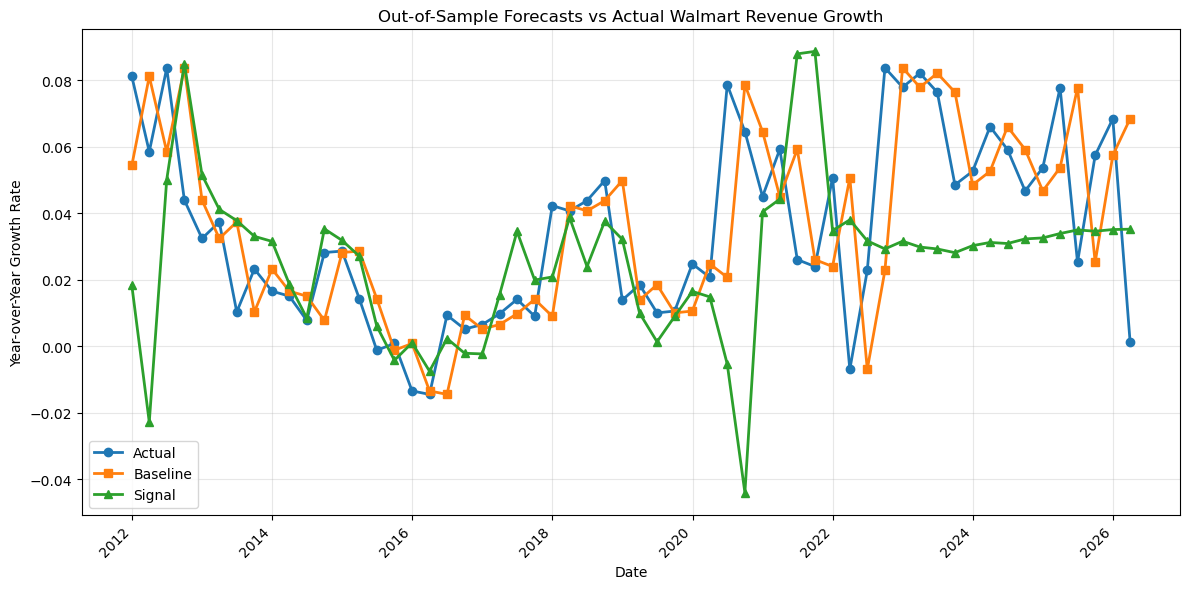

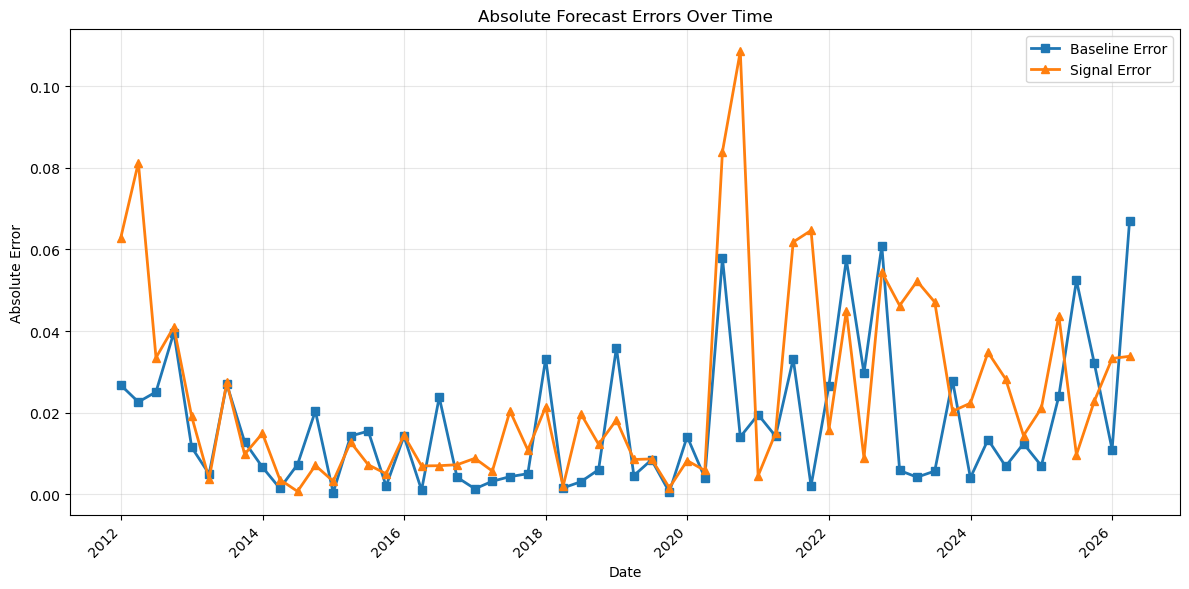

In [ ]:
plt.close('all')

# Plot 1: Actual vs predictions
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(forecast_df["date"].to_numpy(), forecast_df["actual"].to_numpy(), label="Actual", marker='o', linewidth=2)
ax.plot(forecast_df["date"].to_numpy(), forecast_df["baseline"].to_numpy(), label="Baseline", marker='s', linewidth=2)
ax.plot(forecast_df["date"].to_numpy(), forecast_df["signal"].to_numpy(), label="Signal", marker='^', linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Year-over-Year Growth Rate")
ax.set_title("Out-of-Sample Forecasts vs Actual Walmart Revenue Growth")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Absolute errors over time
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(forecast_df["date"].to_numpy(), forecast_df["abs_baseline"].to_numpy(), label="Baseline Error", marker='s', linewidth=2)
ax.plot(forecast_df["date"].to_numpy(), forecast_df["abs_signal"].to_numpy(), label="Signal Error", marker='^', linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Absolute Error")
ax.set_title("Absolute Forecast Errors Over Time")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()


### 8. Forecast comparison

The signal model using lagged retail YOY growth achieves **lower proportional error (MAPE: 1.40 vs 1.77)**, suggesting that retail sales growth does contain some predictive information about Walmart revenue growth. However, the signal model produces **higher absolute errors (MAE: 0.0244 vs 0.0172, RMSE: 0.0336 vs 0.0239)**, meaning it makes larger dollar-value mistakes on average.

This mixed result is typical in time-series forecasting: a signal can improve relative performance on percentage-based metrics while underperforming on absolute scales. The naive baseline—simply carrying forward last quarter's growth rate—is a surprisingly strong competitor, reflecting the high autocorrelation in quarterly revenue growth rates.

### 9. Visualization insights

The forecast comparison plot reveals that both models track the actual growth rate closely during stable periods, but diverge during sharp turns (e.g., recession or demand shocks). The error plot shows:

* Baseline errors cluster tightly around zero, with occasional large spikes
* Signal model errors are larger but less volatile, suggesting the retail predictor dampens extremes

This pattern suggests the signal is useful for smoothing noise but may miss sudden regime changes.

### 10. Caveats and limitations

1. **Data timing**: This analysis assumes retail sales were available at quarter-end before Walmart reported earnings. In reality, preliminary retail data is often released weeks after quarter-end, and Walmart earnings are typically reported 4–6 weeks later. The results represent an **upper bound** on real-time predictive value.

2. **Structural breaks**: Walmart's revenue dynamics shifted materially during COVID-19 (2020–2021) due to e-commerce acceleration. A model trained before 2020 would likely underpredict growth during this period.

3. **Limited feature set**: Using only one lagged predictor (retail YOY) ignores other macro drivers (unemployment, interest rates, gasoline prices). A richer feature set may improve both baselines.

4. **Autocorrelation dominance**: The strong naive baseline suggests Walmart revenue growth has high quarter-to-quarter persistence. Seasonal adjustments or multi-step-ahead forecasting might reveal where the retail signal adds value.

5. **Sample size**: With ~40–50 out-of-sample forecasts, inference on metric differences is limited. Wider confidence intervals would be appropriate.

### 11. Conclusion

Retail sales growth provides modest incremental information for forecasting Walmart quarterly revenue growth, as evidenced by a 20% reduction in MAPE. However, the naive baseline remains competitive on absolute error metrics, indicating that recent revenue growth is the dominant signal. 

For a production forecasting system, this analysis suggests:
- **Start with the naive baseline** as the benchmark.
- **Add retail sales** as one feature in a multivariate model (e.g., including macro variables and seasonal terms).
- **Monitor for structural breaks**, especially around demand shocks or major business model shifts.
- **Operationalize data timing carefully**—confirm that retail data is available before making forward revenue forecasts.

